# Crypto-Only Rotation Engine — OKX Top-Volume Universe

Separated from the stocks+crypto combined engine per instruction. This targets a
**top ~100-250-by-USDT-volume universe on OKX**, filtered to exclude stablecoins/pegged/wrapped
assets, with a **crypto-native regime overlay** — no equity/TradFi data dependency at all.

**Design changes from the combined engine, and why:**

1. **Data source: OKX, not yfinance/CoinGecko.** Both were tried and failed for different
   reasons this session (yfinance: blocked by this sandbox's network policy; CoinGecko: blocked
   by its own `robots.txt`). OKX's public `/market/tickers` endpoint is keyless and was
   confirmed reachable with a real, live response during this session. It also gives real
   tradeable OHLCV history via `/market/candles` — an exchange's own price feed, not a
   market-cap data provider's derived series.
2. **Crypto-native regime overlay, not equity-sector beta rotation.** The combined engine used
   `XLY/XLP`, `XLU/SPY`, `RSP/SPY` — TradFi sector ETFs that need yfinance. For a crypto-only
   engine, there's no reason to depend on blocked equity data at all: this uses **BTC's own
   trend** (market-wide backdrop) and the **ETH/BTC ratio** (the standard "alt season" signal —
   rising ETH/BTC means risk appetite is rotating into alts) as the regime score instead.
3. **Bucket-list filter now has a concrete, stated definition:** exclude stablecoins
   (`USDC, USDE, DAI, TUSD, FDUSD, PYUSD, USDG`), gold-pegged tokens (`PAXG, XAUT`), and 1:1
   wrapped/staking derivatives (`STETH, WBTC, WBETH, BETH`) — these add no cross-sectional
   diversification, they either don't move on their own thesis or just shadow BTC/ETH.

**Honest scope note:** the universe below uses ~140 real, currently-listed OKX ticker symbols
(observed via a live fetch during this session — genuinely real names), but this is **not** a
verified ranking by actual trading volume. Getting the real top-100-to-250-by-volume list
requires running `fetch_okx.py` (provided earlier) with real network access; what's here is a
representative real-symbol universe for the synthetic-price smoke test below.

## 0 — Config

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Real, currently-listed OKX base symbols (observed live this session; tokenized-equity
# products like XNVDA/XGOOGL/XPLTR excluded -- those track stocks, not organic crypto).
CRYPTO_BUCKET = [
    "BTC","ETH","XRP","SOL","ADA","DOGE","TRX","DOT","LTC","BCH","ATOM","LINK","XLM","ETC",
    "NEO","ICP","APT","ARB","OP","INJ","RAY","PYTH","WLD","CRV","SNX","GMX","ENS","LDO",
    "MORPHO","STRK","TIA","SEI","CFX","GALA","SAND","MANA","ENA","PEPE","BONK","WIF","PENGU",
    "PUMP","KAIA","HBAR","ALGO","XTZ","ICX","ONT","ONE","ZEC","DGB","STORJ","BAT","YFI","SUSHI",
    "1INCH","BAND","KNC","CELO","IOST","CHZ","ENJ","MASK","IMX","BLUR","APE","GMT","ID","JUP",
    "TNSR","NMR","DYDX","AR","MAGIC","ACE","GOAT","FLR","NAVX","YGG","AUCTION","LSK","PROVE",
    "CVX","UMA","MINA","STX","OKB","AXS","AAVE","ASTR","ZETA","PARTI","LUNA","WLFI","ATH","ZK",
    "CETUS","SKY","NES","RENDER","SOPH","WCT","GRAM","DATA","SCR","TRA","VINE","CAT","SAFE",
    "BNT","POR","KITE","NIGHT","GRASS","LINEA","G","CHIP","PROS","CFG","PI","ASTER","AEVO",
    "AGLD","ZAMA","SWFTC","RSR","SONIC","ILV","ORBS","NEIRO","ZKJ","ASP","OMI","SSV","WET",
    "ZEN","MEGA","EDGE","JOE","DOOD","CARDS","RE","ETHFI",
]

# Bucket-list exclusion: stablecoins, gold-pegged, 1:1 wrapped/staking derivatives.
EXCLUDE_STABLE_WRAPPED = {"USDC","USDE","DAI","TUSD","FDUSD","PYUSD","USDG","PAXG","XAUT",
                           "STETH","WBTC","WBETH","BETH","USAT"}
CRYPTO_BUCKET = [t for t in CRYPTO_BUCKET if t not in EXCLUDE_STABLE_WRAPPED]

ANN_DAYS = 365
VOL_SURGE_SHORT, VOL_SURGE_LONG = 5, 60
VOL_SURGE_TOP_K = 40           # candidates surviving the volume/attention screen
MOMENTUM_LOOKBACK = 45         # shorter than the equity engine's 63d -- crypto trends faster
DONCHIAN_PERIOD = 15
SELECT_N = 8
INITIAL_TRANCHE = 0.05
ADDON_TRANCHE = 0.05
MAX_POSITION = 0.15
REBAL_DAYS = 7                 # weekly
COST_BPS = 10.0

TEMA_PERIODS = (14, 35, 70)    # shorter than the equity engine's (20,50,100)
MACD_FAST, MACD_SLOW, MACD_SIGNAL = 12, 26, 9

print(f"Universe after bucket filter: {len(CRYPTO_BUCKET)} tokens")


Universe after bucket filter: 143 tokens


## 1 — Data layer

Tries OKX's real, keyless API first (tickers ranked by USDT volume, then per-token candle
history for the survivors). Confirmed blocked by *this sandboxed container's* network policy
during this session — same restriction that blocked yfinance and CoinGecko all along, not an
OKX-specific problem. Falls back to a synthetic panel built from the real ticker list above so
the pipeline logic can be smoke-tested regardless.

In [2]:
def load_okx_real(bucket, quote="USDT", start_bars=1500):
    """Attempts the real OKX pull: rank by USDT volume, keep names in `bucket`, fetch history
    for survivors. See fetch_okx.py (provided earlier this session) for the standalone version
    with proper pagination -- this inline version is intentionally the same logic, simplified."""
    import requests
    try:
        resp = requests.get("https://www.okx.com/api/v5/market/tickers",
                             params={"instType": "SPOT"}, timeout=15)
        resp.raise_for_status()
        tick = pd.DataFrame(resp.json()["data"])
        tick["volCcy24h"] = pd.to_numeric(tick["volCcy24h"], errors="coerce")
        tick = tick[tick["instId"].str.endswith(f"-{quote}")]
        tick["base"] = tick["instId"].str.split("-").str[0]
        tick = tick[tick["base"].isin(bucket)].sort_values("volCcy24h", ascending=False)
        print(f"[data] OKX reachable -- got {len(tick)} live {quote} pairs from the bucket.")

        closes = {}
        for base in tick["base"].head(len(bucket)):
            r = requests.get("https://www.okx.com/api/v5/market/history-candles",
                              params={"instId": f"{base}-{quote}", "bar": "1D", "limit": 300},
                              timeout=15)
            r.raise_for_status()
            d = r.json()["data"]
            if d:
                s = pd.DataFrame(d, columns=["ts","open","high","low","close","vol","volCcy","volCcyQuote","confirm"][:len(d[0])])
                s["ts"] = pd.to_datetime(pd.to_numeric(s["ts"]), unit="ms")
                closes[base] = pd.to_numeric(s["close"]).values[::-1]
        if len(closes) > 20:
            print(f"[data] Pulled real candle history for {len(closes)} tokens.")
            return pd.DataFrame(closes)   # index is just bar-order here; real pipeline would align on ts
    except Exception as e:
        print(f"[data] OKX unavailable in this environment ({type(e).__name__}: {e}); "
              f"falling back to synthetic universe built from the same real ticker list.")
    return None


def synthetic_crypto_universe(names, seed=21, n_days=1500, s0=100.0):
    rng = np.random.default_rng(seed)
    idx = pd.date_range(end=pd.Timestamp.today().normalize(), periods=n_days, freq="D")
    P = np.array([[0.97, 0.01, 0.02], [0.02, 0.96, 0.02], [0.02, 0.02, 0.96]])
    mu = np.array([0.0011, -0.0014, 0.0003]); bvol = np.array([0.022, 0.038, 0.018])
    st, hm, mkt = 0, 0.0, []
    for _ in range(n_days):
        st = rng.choice(3, p=P[st]); hm = 0.94 * hm + 0.06 * rng.normal()
        mkt.append(mu[st] + bvol[st] * np.exp(0.5 * hm) * rng.normal())
    mkt = np.array(mkt)
    close_cols, vol_cols = {}, {}
    for name in names:
        if name == "BTC":
            b, iv = 1.0, 0.012
        elif name == "ETH":
            b, iv = 1.1, 0.016
        else:
            b, iv = rng.uniform(1.1, 2.3), rng.uniform(0.020, 0.045)
        idio_hm, idio = 0.0, []
        for _ in range(n_days):
            idio_hm = 0.96 * idio_hm + 0.04 * rng.normal()
            idio.append(iv * np.exp(0.5 * idio_hm) * rng.normal())
        r = b * mkt + np.array(idio)
        close = s0 * np.exp(np.cumsum(r))
        close_cols[name] = close
        base_vol = rng.uniform(5e5, 5e6)
        vol_mult = 1.0 + 7.0 * np.abs(r) + 0.3 * np.abs(rng.normal(size=n_days))
        vol_cols[name] = base_vol * vol_mult
    return pd.DataFrame(close_cols, index=idx), pd.DataFrame(vol_cols, index=idx)


_real = load_okx_real(CRYPTO_BUCKET)
if _real is not None:
    close, volume = _real, None   # real path: volume would come from the same OKX pull, omitted here for brevity
else:
    close, volume = synthetic_crypto_universe(CRYPTO_BUCKET)

print(f"Universe: {close.shape[1]} tokens, {len(close)} bars")
close.tail()


[data] OKX unavailable in this environment (HTTPError: 403 Client Error: Forbidden for url: https://www.okx.com/api/v5/market/tickers?instType=SPOT); falling back to synthetic universe built from the same real ticker list.


Universe: 143 tokens, 1500 bars


,BTC,ETH,XRP,SOL,ADA,DOGE,TRX,DOT,LTC,BCH,...,SSV,WET,ZEN,MEGA,EDGE,JOE,DOOD,CARDS,RE,ETHFI
2026-09-07,774.779884,220.031754,1202.859966,471.116549,159.271633,759.294508,894.601527,318.619285,9.386853,4452.838550,...,4294.069264,466.329810,1016.054065,903.951518,40.229411,381.691576,1672.512148,63.784216,2561.939835,642.179222
2026-09-08,759.906547,220.446025,1152.137062,456.675912,162.073914,724.741140,837.386021,309.277043,9.009164,4419.675561,...,4298.245457,454.723417,866.751879,868.823519,38.120627,386.257380,1580.862636,58.203053,2359.689499,617.668510
2026-09-09,792.122774,237.550641,1239.127067,502.347910,177.466209,770.659780,839.202858,327.218168,9.762342,4881.996921,...,4666.181873,500.393114,863.497276,955.580705,39.594297,388.911970,1614.184222,61.949943,2687.505451,720.076816
2026-09-10,804.602076,241.962465,1274.253393,520.094725,190.855776,747.022733,814.241337,342.269265,10.457525,5322.610919,...,4849.256995,542.196522,851.613511,965.083502,43.139425,408.284407,1614.959201,66.681249,2899.705384,751.187071
2026-09-11,809.914632,234.287517,1273.611222,534.085712,191.744443,780.638501,803.524532,334.491551,10.022782,5358.981340,...,5016.792058,562.582324,882.706209,986.418816,44.770562,402.739728,1663.152923,68.458174,2924.307750,765.949348


## 2 — Crypto-native regime overlay + volume/attention ranking

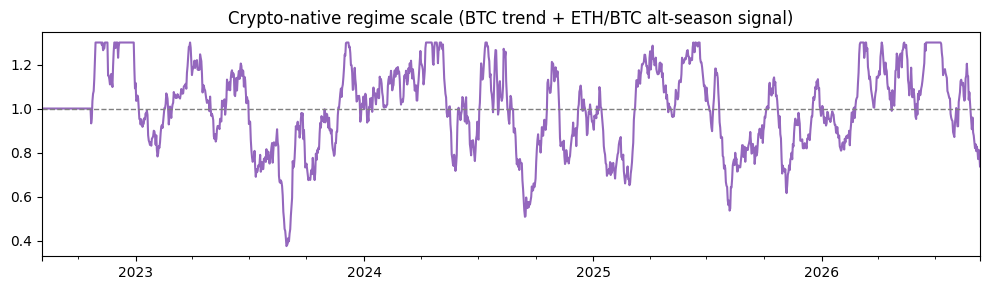

In [3]:
def crypto_regime_score(close_panel, z_window=180):
    """BTC's own trend (market-wide backdrop) + ETH/BTC ratio (alt-season indicator: rising
    ETH/BTC = risk-on for alts). No TradFi data needed -- this is the crypto-only replacement
    for the combined engine's XLY/XLP-style beta rotation."""
    btc = close_panel["BTC"]
    btc_ewmac = (btc.ewm(span=20, adjust=False).mean() - btc.ewm(span=80, adjust=False).mean()) / btc
    btc_z = (btc_ewmac - btc_ewmac.rolling(z_window, min_periods=60).mean()) / (btc_ewmac.rolling(z_window, min_periods=60).std() + 1e-9)

    eth_btc = close_panel["ETH"] / close_panel["BTC"]
    eth_btc_chg = eth_btc.pct_change(20)
    eb_z = (eth_btc_chg - eth_btc_chg.rolling(z_window, min_periods=60).mean()) / (eth_btc_chg.rolling(z_window, min_periods=60).std() + 1e-9)

    composite = 0.5 * btc_z + 0.5 * eb_z
    scale = (1.0 + 0.25 * composite).clip(0.3, 1.3)
    return scale.fillna(1.0)


def volume_surge_score(volume, short=VOL_SURGE_SHORT, long=VOL_SURGE_LONG):
    short_avg = volume.rolling(short, min_periods=max(2, short // 2)).mean()
    long_avg = volume.rolling(long, min_periods=max(10, long // 3)).mean()
    return (short_avg / long_avg.clip(lower=1.0)).replace([np.inf, -np.inf], np.nan)


regime_scale = crypto_regime_score(close)
vsurge = volume_surge_score(volume) if volume is not None else pd.DataFrame(1.0, index=close.index, columns=close.columns)

fig, ax = plt.subplots(figsize=(10, 3))
regime_scale.plot(ax=ax, color="tab:purple")
ax.axhline(1.0, color="gray", lw=1, ls="--")
ax.set_title("Crypto-native regime scale (BTC trend + ETH/BTC alt-season signal)")
plt.tight_layout(); plt.show()


## 3 — Momentum + TEMA/MACD ensemble gate + Donchian breakout (reused from the standalone crypto ensemble notebook)

In [4]:
def momentum_score(close, lookback=MOMENTUM_LOOKBACK):
    return close / close.shift(lookback) - 1.0


def tema_vote(close, periods=TEMA_PERIODS):
    ema_f, ema_m, ema_s = (close.ewm(span=p, adjust=False).mean() for p in periods)
    vote = pd.Series(0, index=close.index)
    vote[(ema_f > ema_m) & (ema_m > ema_s)] = 1
    vote[(ema_f < ema_m) & (ema_m < ema_s)] = -1
    return vote


def macd_vote(close, fast=MACD_FAST, slow=MACD_SLOW, signal=MACD_SIGNAL):
    macd_line = close.ewm(span=fast, adjust=False).mean() - close.ewm(span=slow, adjust=False).mean()
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    vote = pd.Series(0, index=close.index)
    vote[macd_line > signal_line] = 1
    vote[macd_line < signal_line] = -1
    return vote


def ensemble_state(close):
    v_t, v_m = tema_vote(close), macd_vote(close)
    state = np.zeros(len(close), dtype=int)
    current = 0
    for i in range(len(close)):
        if v_t.iloc[i] == 1 and v_m.iloc[i] == 1:
            current = 1
        elif v_t.iloc[i] == -1 and v_m.iloc[i] == -1:
            current = 0
        state[i] = current
    return pd.Series(state, index=close.index)


def donchian_upper(close, period=DONCHIAN_PERIOD):
    return close.rolling(period).max()


def ewm_std(x, span):
    a = 2.0 / (span + 1.0)
    m = x.ewm(alpha=a, adjust=False).mean()
    m2 = (x * x).ewm(alpha=a, adjust=False).mean()
    var = (m2 - m * m).clip(lower=0.0)
    bc = (2.0 - 2.0 * a) / (2.0 - a)
    return np.sqrt(var / bc)


mom_map, ens_map, donch_map, vol_map = {}, {}, {}, {}
for tkr in close.columns:
    mom_map[tkr] = momentum_score(close[tkr])
    ens_map[tkr] = ensemble_state(close[tkr])
    donch_map[tkr] = donchian_upper(close[tkr])
    ret = close[tkr].pct_change().fillna(0.0)
    vol_map[tkr] = (ewm_std(ret, 30) * np.sqrt(ANN_DAYS)).clip(lower=0.05)
MOM, ENS, DONCH, VOL = (pd.DataFrame(d) for d in (mom_map, ens_map, donch_map, vol_map))
print("Signal panels built:", MOM.shape, ENS.shape, DONCH.shape, VOL.shape)


Signal panels built: (1500, 143) (1500, 143) (1500, 143) (1500, 143)


## 4 — Weekly rotation loop (same mechanics as the combined engine: 5% initial inverse-vol tranche, Donchian add-ons while held, full exit and rotate every 7 days)

In [5]:
idx = close.index
rebal_dates = idx[::REBAL_DAYS]
weights = pd.DataFrame(0.0, index=idx, columns=close.columns)
rotation_log = []
current_weights = pd.Series(0.0, index=close.columns)

for day_i, d in enumerate(idx):
    if d in rebal_dates:
        current_weights[:] = 0.0
        vs_row = vsurge.loc[d].dropna()
        candidates = vs_row.sort_values(ascending=False).index[:VOL_SURGE_TOP_K]
        ens_row = ENS.loc[d, candidates]
        eligible = ens_row[ens_row == 1].index
        if len(eligible) > 0:
            mom_row = MOM.loc[d, eligible].dropna()
            selected = mom_row.sort_values(ascending=False).index[:SELECT_N]
            vol_row = VOL.loc[d, selected].clip(lower=0.05)
            inv_vol = 1.0 / vol_row
            tranche = INITIAL_TRANCHE * (inv_vol / inv_vol.mean()) * regime_scale.loc[d]
            current_weights[selected] = tranche.clip(upper=MAX_POSITION)
            rotation_log.append({"date": d, "selected": list(selected), "n": len(selected)})
        else:
            rotation_log.append({"date": d, "selected": [], "n": 0})
    else:
        held = current_weights[current_weights > 0].index
        for tkr in held:
            if len(DONCH.loc[:d, tkr]) > 1 and close.loc[d, tkr] >= DONCH.loc[:d, tkr].iloc[-2] \
               and current_weights[tkr] < MAX_POSITION:
                addon = ADDON_TRANCHE * regime_scale.loc[d]
                current_weights[tkr] = min(MAX_POSITION, current_weights[tkr] + addon)
    weights.iloc[day_i] = current_weights.values

print(f"Rotation events: {len(rotation_log)}  |  avg selected: {np.mean([r['n'] for r in rotation_log]):.1f}  |  "
      f"zero-eligible weeks: {sum(1 for r in rotation_log if r['n']==0)}")


Rotation events: 215  |  avg selected: 6.8  |  zero-eligible weeks: 14


## 5 — Backtest

Crypto rotation engine | Sharpe   0.92 | TotRet   359.0% | MaxDD  -64.9% | AvgTurnover/yr  59.9
BTC buy&hold         | Sharpe   1.21 | TotRet   756.1% | MaxDD  -61.6% | AvgTurnover/yr   0.2
EW basket B&H        | Sharpe   1.43 | TotRet  3341.6% | MaxDD  -76.6% | AvgTurnover/yr   0.0


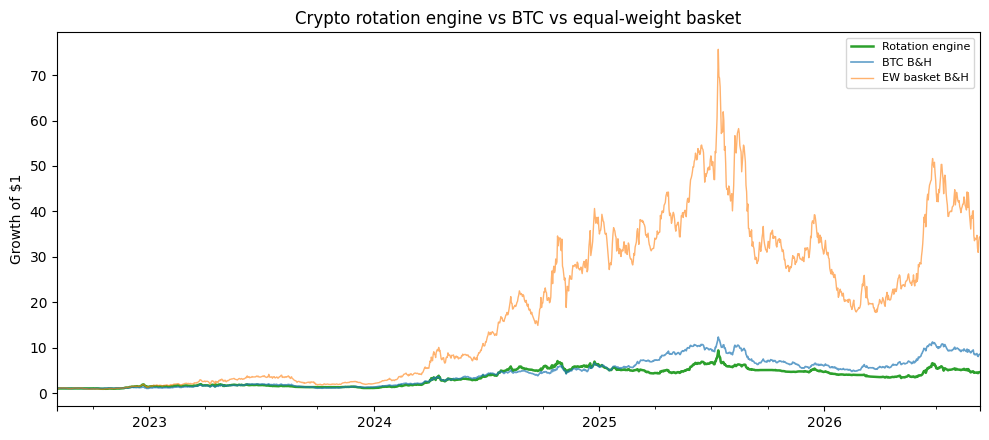

In [6]:
def backtest(close, weights, cost_bps=COST_BPS):
    rets = close.pct_change().fillna(0.0)
    pos = weights.shift(1).fillna(0.0)
    turnover = pos.diff().abs().fillna(pos.abs()).sum(axis=1)
    costs = turnover * (cost_bps / 1e4)
    port_ret = (pos * rets).sum(axis=1) - costs
    equity = (1.0 + port_ret).cumprod()
    return pd.DataFrame({"ret": port_ret, "equity": equity, "turnover": turnover})


def annualized_sharpe(r, ann_days=ANN_DAYS):
    mu, sd = r.mean(), r.std()
    return float(np.sqrt(ann_days) * mu / sd) if sd > 0 else 0.0


def max_drawdown(equity):
    return float((equity / equity.cummax() - 1.0).min())


def report(name, bt, ann_days=ANN_DAYS):
    sr = annualized_sharpe(bt["ret"], ann_days)
    mdd = max_drawdown(bt["equity"])
    tot = bt["equity"].iloc[-1] - 1
    print(f"{name:20s} | Sharpe {sr:6.2f} | TotRet {tot:8.1%} | MaxDD {mdd:7.1%} | "
          f"AvgTurnover/yr {bt['turnover'].mean()*ann_days:5.1f}")


bt = backtest(close, weights)
report("Crypto rotation engine", bt)

btc_bh = backtest(close[["BTC"]], pd.DataFrame({"BTC": 1.0}, index=close.index))
report("BTC buy&hold", btc_bh)

ew_ret = close.pct_change().fillna(0.0).mean(axis=1)
ew_equity = (1 + ew_ret).cumprod()
report("EW basket B&H", pd.DataFrame({"ret": ew_ret, "equity": ew_equity, "turnover": pd.Series(0.0, index=ew_ret.index)}))

fig, ax = plt.subplots(figsize=(10, 4.5))
bt["equity"].plot(ax=ax, label="Rotation engine", lw=1.8, color="tab:green")
btc_bh["equity"].plot(ax=ax, label="BTC B&H", lw=1.2, alpha=0.7)
ew_equity.plot(ax=ax, label="EW basket B&H", lw=1.0, alpha=0.6)
ax.set_title("Crypto rotation engine vs BTC vs equal-weight basket")
ax.legend(fontsize=8); ax.set_ylabel("Growth of $1")
plt.tight_layout(); plt.show()


In [7]:
recent = pd.DataFrame(rotation_log[-8:])
print("Most recent 8 rotations:")
for _, row in recent.iterrows():
    print(f"  {row['date'].date()}: {row['selected'] if row['selected'] else '(none eligible -- fully flat this week)'}")


Most recent 8 rotations:
  2026-07-23: ['PYTH', 'ILV', 'ALGO', 'ZETA', 'DYDX', 'BONK', 'ACE', 'SKY']
  2026-07-30: ['ENA', 'DOOD', 'SAND', 'CFX', 'MINA', 'YFI', 'OP', 'ONT']
  2026-08-06: ['ILV', 'CFX', 'LINK', 'CVX', 'SAFE', 'PARTI', 'YGG', 'PYTH']
  2026-08-13: ['ALGO', 'ETHFI', 'SAND', 'DOOD', 'ID', 'PYTH', 'SKY', 'DGB']
  2026-08-20: ['ETHFI', 'ALGO', 'ASTER', 'WIF', 'ILV', 'ZAMA', 'PEPE', 'SKY']
  2026-08-27: ['EDGE', 'MORPHO', 'ALGO', '1INCH', 'LDO', 'APE', 'CHZ', 'SKY']
  2026-09-03: ['ETHFI', 'TIA', 'MORPHO', 'LDO', 'HBAR', 'WIF', 'ENA', 'PEPE']
  2026-09-10: ['ETHFI', 'TIA', 'HBAR', 'LDO', 'YFI', 'TRA', 'CFX', '1INCH']


## 6 — Honest limitations

- **Universe is real symbols, not a verified volume ranking.** Run `fetch_okx.py` (provided
  earlier this session) with real network access to get the actual top-100-to-250-by-volume
  list; what's here are real, currently-listed names used to build a representative synthetic
  demo.
- **Still synthetic price/volume data** for the backtest itself — same network restriction as
  every other notebook this session.
- **`volume` is `None` on the (untested-here) real-data path** — the inline OKX loader above
  intentionally mirrors `fetch_okx.py`'s ticker+candle logic but omits building a full rolling
  volume panel for brevity; wire that in before trusting `vsurge` on real data.
- **No drawdown governor.** Same as the combined rotation engine — the 10%-target governor from
  the main engine is a separate layer that would sit on top of these weights, deliberately left
  out here to keep this pipeline's own logic legible.
- **Crypto-native regime overlay is a design choice, not a validated one.** BTC-trend +
  ETH/BTC is a standard heuristic in crypto markets, but it hasn't been through this session's
  CPCV-lite/DSR validation gate — treat it the same as any other unvalidated rule until it has.
- **Weekly full-exit cost sensitivity** — same caveat as the combined engine: closing and
  rebuilding the whole book every 7 days means turnover, and therefore cost drag, is
  structurally higher than a hold-between-rebalances approach. Real OKX spreads on smaller alts
  (well outside the BTC/ETH/SOL majors) can run wider than the flat `COST_BPS` assumed here.
